### Passo 01: Importando bibliotecas

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

### Passo 02: Delimitando o período

In [4]:
start_date = "2020-01-01"
end_date = datetime.now().strftime('%Y-%m-%d')

### Passo 03: Delimitando as empresas analisadas

In [6]:
tickers = {
    "Petrobras ON": "PETR3.SA",
    "Petrobras PN": "PETR4.SA",
    "PRIO": "PRIO3.SA",
    "Brava Energia": "BRAV3.SA",
    "PetroReconcavo": "RECV3.SA",
    "Vibra Energia": "VBBR3.SA",
    "Ultrapar": "UGPA3.SA",
    "Raízen": "RAIZ4.SA",
    "IBOVESPA": "^BVSP"
}

### Passo 04: Criando o DataFrame principal

In [8]:
df = pd.DataFrame()

for empresa, ticker in tickers.items():
    dados = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    df[empresa] = dados["Close"]

In [9]:
petroleo = yf.download("CL=F", start=start_date, end=end_date, auto_adjust=True, progress=False)
df["Petróleo"] = petroleo["Close"]

### Passo 05: Adição de Métricas necessárias 

In [11]:
df = df.dropna() #Removendo datas sem negociação
petroleo_mean = df["Petróleo"].mean() #Média
df_norm = ((df / df.iloc[0]) - 1) * 100 #Normalizando as séries

### Passo 06: Validação inicial dos dataframes das séries determinadas

In [13]:
print(df.describe())
print(df.head())
print(df.tail())
print(df.dtypes)

       Petrobras ON  Petrobras PN         PRIO  Brava Energia  PetroReconcavo  \
count   1198.000000   1198.000000  1198.000000    1198.000000     1198.000000   
mean      25.858942     23.520883    38.771845      27.737778       14.156400   
std       10.751841      9.929538    10.981341       8.316440        2.986317   
min        7.942264      7.518563    16.723139      13.348629        8.793512   
25%       16.145339     13.896236    31.679117      19.391790       11.901153   
50%       28.455593     26.712394    39.609999      28.491191       13.748055   
75%       32.542966     29.902618    45.367499      33.646993       15.926469   
max       53.919601     48.523716    72.099998      49.622643       24.095657   

       Vibra Energia     Ultrapar       Raízen       IBOVESPA     Petróleo  
count    1198.000000  1198.000000  1198.000000    1198.000000  1198.000000  
mean       17.639900    17.241185     3.095423  127677.866444    78.163648  
std         5.308551     5.420337     1

### Passo 07: Validação gráfica da "Normalização das empresas do setor petrolífero"

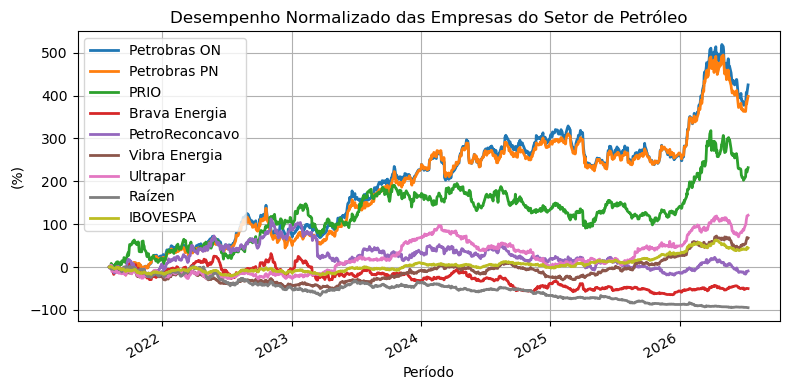

In [15]:
plt.figure(figsize=(8,4))
df_norm.drop(columns="Petróleo").plot(ax=plt.gca(), linewidth=2)

plt.title("Desempenho Normalizado das Empresas do Setor de Petróleo")
plt.xlabel("Período")
plt.ylabel("(%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("grafico_empresas.png", dpi=300, bbox_inches="tight")
plt.show()

### Passo 08: Validação gráfica da "Normalização do Petróleo (Futuro)"

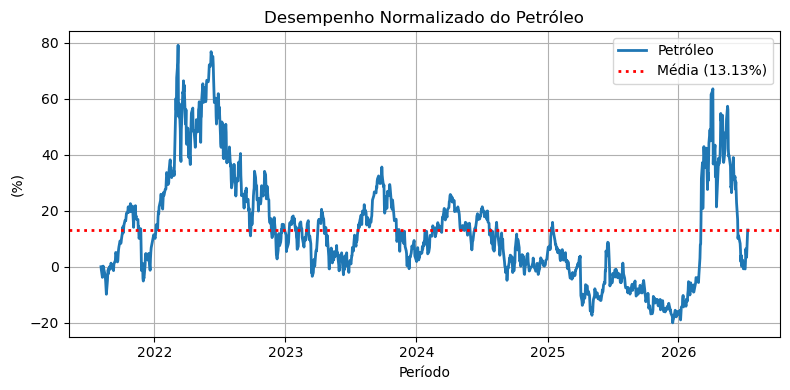

In [17]:
pet_norm = df_norm["Petróleo"]
x = np.arange(len(pet_norm))
coef = np.polyfit(x, pet_norm, 1)
tendencia = np.polyval(coef, x)

plt.figure(figsize=(8,4))
plt.plot(pet_norm.index, pet_norm, linewidth=2, label="Petróleo")
plt.axhline(y=pet_norm.mean(), color="red", linestyle=":", linewidth=2, label=f"Média ({pet_norm.mean():.2f}%)")

plt.title("Desempenho Normalizado do Petróleo")
plt.xlabel("Período")
plt.ylabel("(%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("grafico_petroleo.png", dpi=300, bbox_inches="tight")
plt.show()